# Analytical & Numerical Formulation for BVP

## 1. Problem Statement
Solve the second-order Boundary Value Problem (BVP):
$$y'' + 4y = 4x, \quad y(0) = 0, \quad y'\!\left(\frac{\pi}{2}\right) = 0$$

---

## 2. Analytical Solution

### Step 1: Homogeneous Solution ($y_c$)
Solving the homogeneous equation:
$$y'' + 4y = 0$$

Characteristic equation:
$$r^2 + 4 = 0 \implies r = \pm 2i$$

$$y_h(x) = C_1 \cos(2x) + C_2 \sin(2x)$$

### Step 2: Obtaining Particular Solution ($y_p$)
Assuming a form $y_p(x) = Ax + B$.
Then $y_p' = A$ and $y_p'' = 0$.

Substituting into $y'' + 4y = 4x$:
$$0 + 4(Ax + B) = 4x$$
$$4Ax + 4B = 4x$$

Equating coefficients:
* $4A = 4 \implies A = 1$
* $4B = 0 \implies B = 0$

Thus, $y_p(x) = x$.

### Step 3: Formulating General Solution
$$y(x) = y_h(x) + y_p(x) = C_1 \cos(2x) + C_2 \sin(2x) + x$$

Derivative:
$$y'(x) = -2C_1 \sin(2x) + 2C_2 \cos(2x) + 1$$

### Step 4: Applying Boundary Conditions
1. **At $x = 0$ ($y(0) = 0$):**
   $$y(0) = C_1 \cos(0) + C_2 \sin(0) + 0 = 0 \implies C_1 = 0$$

2. **At $x = \frac{\pi}{2}$ ($y'\!\left(\frac{\pi}{2}\right) = 0$):**
   $$y'\!\left(\frac{\pi}{2}\right) = -2C_1 \sin(\pi) + 2C_2 \cos(\pi) + 1 = 0$$
   Since $C_1 = 0$ and $\cos(\pi) = -1$:
   $$-2C_2 + 1 = 0 \implies C_2 = \frac{1}{2}$$

### Final Analytical Solution
$$y(x) = \frac{1}{2}\sin(2x) + x$$

---

## 3. Finite Difference Discretization

### Centered Difference Approximations
$$y'_i = \frac{y_{i+1} - y_{i-1}}{2h}, \quad y''_i = \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2}$$

Substituting $y''_i$ into the ODE $y'' + 4y = 4x$:
$$\frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + 4y_i = 4x_i$$

Multiplying through by $h^2$:
$$y_{i-1} - 2y_i + y_{i+1} + 4y_i h^2 = 4x_i h^2$$
$$y_{i-1} + (4h^2 - 2)y_i + y_{i+1} = 4x_i h^2$$

---

## 4. Boundary Condition Handling (Ghost Node Method)

For node $i = n+1$ at the right boundary $x_{n+1} = \frac{\pi}{2}$:
$$y_{n} + (4h^2 - 2)y_{n+1} + y_{n+2} = 4x_{n+1}h^2$$

Using central difference for $y'\!\left(\frac{\pi}{2}\right) = 0$:
$$\frac{y_{n+2} - y_n}{2h} = 0 \implies y_{n+2} = y_n$$

Substituting the ghost node $y_{n+2} = y_n$ back into the grid equation, we obtain the last equation:
$$y_n + (4h^2 - 2)y_{n+1} + y_n = 4x_{n+1}h^2$$
$$2y_n + (4h^2 - 2)y_{n+1} = 4x_{n+1}h^2$$

---

## References

1. Gupta, R. S. (2019). *Elements of Numerical Analysis* (2nd ed.). Cambridge University Press.

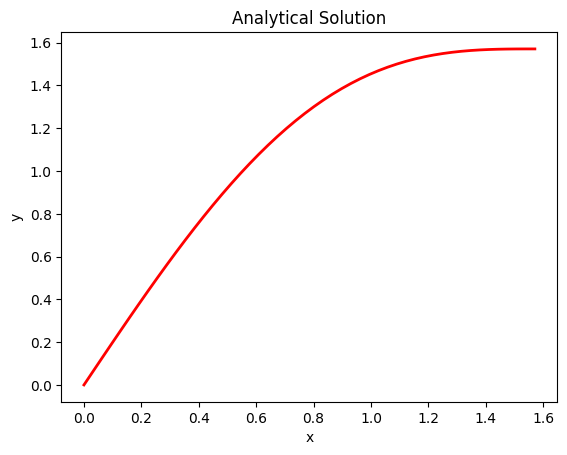

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: (1 / 2) * np.sin(2 * x) + x;

x1 = np.linspace(0, np.pi / 2);
y1 = f(x1);
plt.plot(x1, y1, color = 'red', linewidth = 2);
plt.xlabel('x');
plt.ylabel('y');
plt.title('Analytical Solution');

In [2]:
def backsub(A1, b1):
    m, n = np.shape(A1);

    if m != n:
        raise ValueError("Matrix A must be square!");
        
    if np.size(b1) != n:
        raise ValueError("Matrix-vector size mismatch");

    A = A1.copy();
    b = b1.copy();
    x = np.zeros(n);
    
   

    for i in range(n - 1, -1, -1):
        x[i] = b[i] - np.dot(A[i, i + 1 :], x[i + 1 :]);
        x[i] = x[i] / A[i, i];

    return x
        

In [3]:
A = np.array([(1, 2, 3), (0, 2, 5), (0, 0, 5)])
b = np.array([6, 7, 5]);
x = np.linalg.solve(A, b)
print(x)
y = backsub(A, b)
print(y)

[1. 1. 1.]
[1. 1. 1.]


In [4]:
def thomas_algorithm(A1, b1):
    '''
        This accepts a Tridiagonal system, and solves it using 
        Thomas Algorithm.
    '''
    m, n = np.shape(A1);
    
    if m != n:
        raise ValueError("Matrix A must be a square matrix");
        
    if np.size(b1) != n:
        raise ValueError("Matrix-vector size mismatch");

    # Here we will update the given system so that it becomes 
    # suitable for back substitution.

    A = A1.copy();
    b = b1.copy();

    for i in range(n - 1):

        pivot = A[i + 1, i] / A[i, i];
        A[i + 1, i] = 0;
        A[i + 1, i + 1] = A[i + 1, i + 1] - pivot * A[i, i + 1];
        b[i + 1] = b[i + 1] - pivot * b[i];

    # Now we will send our matrix A, and vector b to the backsub
    x = backsub(A, b);
    return x;

    
    

In [5]:
import numpy as np

# System dimensions and inputs
n = 4
a = np.array([-1.0, -1.0, -1.0])  # Sub-diagonal (length n-1)
b_diag = np.array([2.0, 2.0, 2.0, 2.0])  # Main diagonal (length n)
c = np.array([-1.0, -1.0, -1.0])  # Super-diagonal (length n-1)
b = np.array([1.0, 0.0, 0.0, 1.0])  # Right-hand side (length n)
A = np.diag(b_diag) + np.diag(a, k = -1) + np.diag(c, k = 1);
print(A)
# Run your Thomas algorithm function:
# x = thomas_algorithm(a, b_diag, c, d)

x = thomas_algorithm(A, b);
print(x)

# Expected output check
x_expected = np.array([1.0, 1.0, 1.0, 1.0])
print("Is correct?", np.allclose(x, x_expected))

[[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]
[1. 1. 1. 1.]
Is correct? True


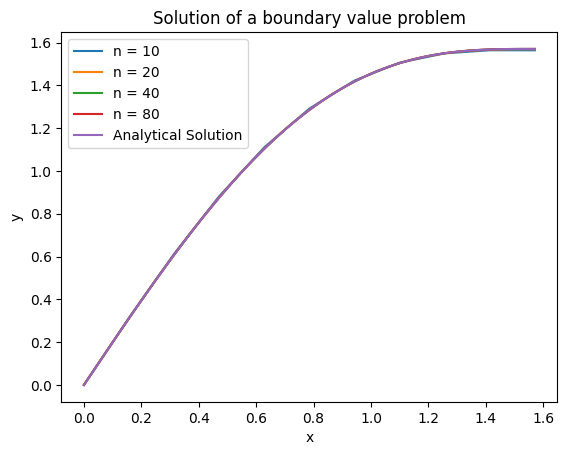

In [6]:
n = 10;
a = 0;
b_v = np.pi / 2;

while n <= 80:
    h = (b_v - a) / n;
    n = int(n);
    x = np.linspace(a, b_v, n + 1);
    main_diagonal = np.full(n + 1, 4 * h ** 2 - 2);
    main_diagonal[0] = 1.0;
    sub_diagonal = np.full(n, 1);
    sub_diagonal[-1] = 2.0;
    super_diagonal = np.full(n, 1);
    super_diagonal[0] = 0;

    A = np.diag(main_diagonal) + np.diag(super_diagonal, k = 1) \
        + np.diag(sub_diagonal, k = -1);
    b = 4 * h ** 2 * x;
    b[0] = 0;
    label_string = "n = " + str(n);
    y = thomas_algorithm(A, b);
    plt.plot(x, y, label = label_string);

    n = n * 2;
    

plt.plot(x, y, label = 'Analytical Solution');
plt.legend();
plt.xlabel('x');
plt.ylabel('y');
plt.title('Solution of a boundary value problem');
plt.show()